In [4]:
# Cell 1: Imports
from nilearn import datasets, plotting
from nilearn.maskers import NiftiMasker
from nilearn.image import mean_img
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

print("✅ All packages imported successfully!")
print(f"Numpy version: {np.__version__}")
print(f"Working directory: {os.getcwd()}")

✅ All packages imported successfully!
Numpy version: 2.4.2
Working directory: /Users/momosarki/Documents/cmn-practical/project2/notebooks


In [6]:
# Cell 2: Load Haxby Dataset (Subject 1)
print("📥 Downloading Haxby dataset (Subject 1)...")
print("⏳ First download may take 2-3 minutes (~200 MB)...\n")

haxby = datasets.fetch_haxby(subjects=[1])

print("✅ Dataset loaded!\n")

# Inspect what we got
print("📂 Files included:")
print(f"  Functional data (4D brain): {haxby.func[0]}")
print(f"  VTC mask:                   {haxby.mask_vt[0]}")
print(f"  Whole-brain mask:           {haxby.mask[0]}")
print(f"  Anatomical scan:            {haxby.anat[0]}")
print(f"  Labels file:                {haxby.session_target[0]}")

# Load labels
labels = pd.read_csv(haxby.session_target[0], sep=' ')

print(f"\n📊 Dataset Structure:")
print(f"  Total volumes: {len(labels)}")
print(f"  Runs (chunks): {labels['chunks'].nunique()}")
print(f"\n  Categories:")
print(labels['labels'].value_counts())

📥 Downloading Haxby dataset (Subject 1)...
⏳ First download may take 2-3 minutes (~200 MB)...

[fetch_haxby] Dataset found in /Users/momosarki/nilearn_data/haxby2001
✅ Dataset loaded!

📂 Files included:
  Functional data (4D brain): /Users/momosarki/nilearn_data/haxby2001/subj1/bold.nii.gz
  VTC mask:                   /Users/momosarki/nilearn_data/haxby2001/subj1/mask4_vt.nii.gz
  Whole-brain mask:           /
  Anatomical scan:            /Users/momosarki/nilearn_data/haxby2001/subj1/anat.nii.gz
  Labels file:                /Users/momosarki/nilearn_data/haxby2001/subj1/labels.txt

📊 Dataset Structure:
  Total volumes: 1452
  Runs (chunks): 12

  Categories:
labels
rest            588
scissors        108
face            108
cat             108
shoe            108
house           108
scrambledpix    108
bottle          108
chair           108
Name: count, dtype: int64


In [7]:
# Cell 3: Inspect Labels in Detail

print("📋 Label Distribution:")
print(labels['labels'].value_counts().sort_index())

print(f"\n📊 Volumes per Run:")
print(labels.groupby('chunks').size())

print(f"\n🔍 First 30 volumes (to see structure):")
print(labels.head(30))

print(f"\n✅ Summary:")
print(f"  Total volumes: {len(labels)}")
print(f"  Total runs: {labels['chunks'].nunique()}")
print(f"  Task volumes (non-rest): {(labels['labels'] != 'rest').sum()}")
print(f"  Rest volumes: {(labels['labels'] == 'rest').sum()}")

📋 Label Distribution:
labels
bottle          108
cat             108
chair           108
face            108
house           108
rest            588
scissors        108
scrambledpix    108
shoe            108
Name: count, dtype: int64

📊 Volumes per Run:
chunks
0     121
1     121
2     121
3     121
4     121
5     121
6     121
7     121
8     121
9     121
10    121
11    121
dtype: int64

🔍 First 30 volumes (to see structure):
      labels  chunks
0       rest       0
1       rest       0
2       rest       0
3       rest       0
4       rest       0
5       rest       0
6   scissors       0
7   scissors       0
8   scissors       0
9   scissors       0
10  scissors       0
11  scissors       0
12  scissors       0
13  scissors       0
14  scissors       0
15      rest       0
16      rest       0
17      rest       0
18      rest       0
19      rest       0
20      rest       0
21      face       0
22      face       0
23      face       0
24      face       0
25      face       

🧠 Visualizing brain images...

1. Anatomical scan:


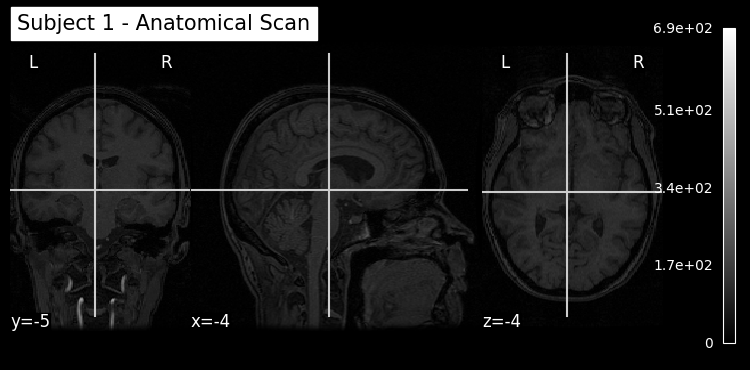


2. Mean functional image (average across all volumes):


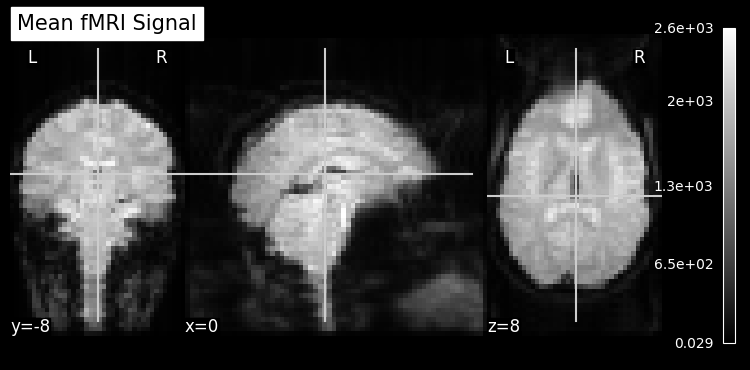


3. Ventral Temporal Cortex (VTC) mask:


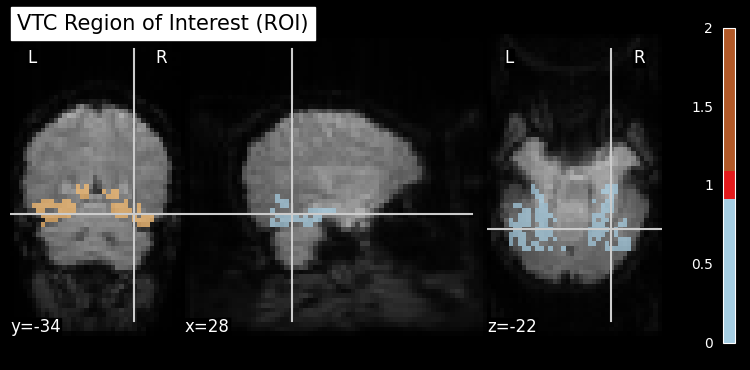


✅ Visualizations complete!
💡 The colored region in the last image is the VTC - where we'll focus our analysis.


In [8]:
# Cell 4: Visualize Brain Data

print("🧠 Visualizing brain images...\n")

# Plot anatomical scan
print("1. Anatomical scan:")
plotting.plot_anat(haxby.anat[0], title="Subject 1 - Anatomical Scan")
plotting.show()

# Plot mean functional image
print("\n2. Mean functional image (average across all volumes):")
mean_func = mean_img(haxby.func[0])
plotting.plot_epi(mean_func, title="Mean fMRI Signal", cmap='gray')
plotting.show()

# Plot VTC mask overlay
print("\n3. Ventral Temporal Cortex (VTC) mask:")
plotting.plot_roi(haxby.mask_vt[0], bg_img=mean_func, 
                  title="VTC Region of Interest (ROI)", cmap='Paired')
plotting.show()

print("\n✅ Visualizations complete!")
print("💡 The colored region in the last image is the VTC - where we'll focus our analysis.")

In [9]:
# Cell 5: Apply VTC Mask and Standardize

print("🎭 Applying VTC mask and standardizing voxels...\n")

# Create masker with VTC region
masker = NiftiMasker(
    mask_img=haxby.mask_vt[0],  # Use ventral temporal cortex mask
    standardize=True,            # Z-score each voxel (mean=0, std=1)
    detrend=False
)

# Apply mask: Transform 4D brain data → 2D matrix
X = masker.fit_transform(haxby.func[0])

# Get labels and runs
y = labels['labels'].values
runs = labels['chunks'].values

print("✅ Masking complete!\n")
print(f"📊 Data Shape:")
print(f"  Original 4D brain data: {haxby.func[0]}")
print(f"  After masking (2D matrix): {X.shape}")
print(f"    → {X.shape[0]} volumes (timepoints)")
print(f"    → {X.shape[1]} voxels in VTC")
print(f"\n  Labels shape: {y.shape}")
print(f"  Runs shape: {runs.shape}")

print(f"\n📈 Data Statistics:")
print(f"  Mean voxel value: {X.mean():.2f} (should be ~0 due to standardization)")
print(f"  Std of voxel values: {X.std():.2f} (should be ~1 due to standardization)")
print(f"  Min value: {X.min():.2f}")
print(f"  Max value: {X.max():.2f}")

🎭 Applying VTC mask and standardizing voxels...



/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/680953675.py:13: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(haxby.func[0])
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/680953675.py:13: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  X = masker.fit_transform(haxby.func[0])
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/680953675.py:13: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  X = masker.fit_transform(haxby.func[0])

✅ Masking complete!

📊 Data Shape:
  Original 4D brain data: /Users/momosarki/nilearn_data/haxby2001/subj1/bold.nii.gz
  After masking (2D matrix): (1452, 577)
    → 1452 volumes (timepoints)
    → 577 voxels in VTC

  Labels shape: (1452,)
  Runs shape: (1452,)

📈 Data Statistics:
  Mean voxel value: 0.00 (should be ~0 due to standardization)
  Std of voxel values: 1.00 (should be ~1 due to standardization)
  Min value: -4.94
  Max value: 6.10


In [10]:
# Check if voxels actually vary over time
print("Voxel 2 across first 20 volumes:")
print(X[:20, 2])

print("\nVariance of voxel 2 (should be ~1.0):")
print(X[:, 2].var())

print("\nVoxel 2 statistics:")
print(f"  Min: {X[:, 2].min():.2f}")
print(f"  Max: {X[:, 2].max():.2f}")
print(f"  Mean: {X[:, 2].mean():.2f}")
print(f"  Std: {X[:, 2].std():.2f}")


Voxel 2 across first 20 volumes:
[-0.3894043  -0.78263474 -0.7170963  -0.5040965  -0.3730197  -1.1758652
 -0.25832748  0.03659534  0.10213374  0.02021074 -0.16001987 -0.5204811
 -0.4221735  -0.4057889  -0.5368657  -0.5532503  -0.5860195  -0.96286535
 -0.81540394 -1.1594806 ]

Variance of voxel 2 (should be ~1.0):
0.99999994

Voxel 2 statistics:
  Min: -2.83
  Max: 2.38
  Mean: 0.00
  Std: 1.00


In [11]:
# Cell 6: Remove Rest Periods

print("🗑️ Removing rest volumes (keeping only task data)...\n")

# Filter out rest
mask_task = y != 'rest'
X_task = X[mask_task]
y_task = y[mask_task]
runs_task = runs[mask_task]

print("✅ Rest periods removed!\n")
print(f"📊 Task Data:")
print(f"  Shape: {X_task.shape}")
print(f"    → {X_task.shape[0]} task volumes")
print(f"    → {X_task.shape[1]} voxels")

print(f"\n📋 Category Distribution:")
task_counts = pd.Series(y_task).value_counts().sort_index()
print(task_counts)

print(f"\n✅ Summary:")
print(f"  Original volumes: {len(y)}")
print(f"  Rest volumes removed: {(y == 'rest').sum()}")
print(f"  Task volumes remaining: {len(y_task)}")
print(f"  Categories: {len(np.unique(y_task))}")

🗑️ Removing rest volumes (keeping only task data)...

✅ Rest periods removed!

📊 Task Data:
  Shape: (864, 577)
    → 864 task volumes
    → 577 voxels

📋 Category Distribution:
bottle          108
cat             108
chair           108
face            108
house           108
scissors        108
scrambledpix    108
shoe            108
Name: count, dtype: int64

✅ Summary:
  Original volumes: 1452
  Rest volumes removed: 588
  Task volumes remaining: 864
  Categories: 8


In [18]:
# Cell 7: Sanity Check - Test One SVM Pair (Faces vs Houses)

print("🧪 SANITY CHECK: Testing one SVM pair...\n")
print("Testing: Faces vs. Houses")
print("=" * 60)

# Filter to faces vs houses only
mask_pair = (y_task == 'face') | (y_task == 'house')
X_pair = X_task[mask_pair]
y_pair = y_task[mask_pair]
runs_pair = runs_task[mask_pair]

print(f"\nPair data:")
print(f"  Total samples: {len(y_pair)}")
print(f"  Faces: {(y_pair == 'face').sum()}")
print(f"  Houses: {(y_pair == 'house').sum()}")
print(f"  Voxels: {X_pair.shape[1]}")

# Leave-one-run-out CV
print(f"\n🔄 Running Leave-One-Run-Out Cross-Validation...")
logo = LeaveOneGroupOut()
svm = SVC(kernel='linear', C=1.0)
scores = []

fold_num = 0
for train_idx, test_idx in logo.split(X_pair, y_pair, groups=runs_pair):
    fold_num += 1
    X_train, X_test = X_pair[train_idx], X_pair[test_idx]
    y_train, y_test = y_pair[train_idx], y_pair[test_idx]
    
    svm.fit(X_train, y_train)
    score = svm.score(X_test, y_test)
    scores.append(score)
    
    print(f"  Fold {fold_num:2d}: {score:6.1%} (test size: {len(y_test)})")

accuracy = np.mean(scores)
std_dev = np.std(scores)

print(f"\n" + "=" * 60)
print(f"📊 RESULTS:")
print(f"  Mean Accuracy: {accuracy:.1%}")
print(f"  Std Dev: {std_dev:.1%}")
print(f"  Chance Level: 50.0%")
print(f"  Above Chance: {accuracy > 0.5}")

if accuracy > 0.75:
    print(f"\n✅ EXCELLENT! Accuracy well above chance.")
    print(f"   Pipeline is working correctly!")
elif accuracy > 0.60:
    print(f"\n✅ GOOD! Accuracy above chance.")
    print(f"   Pipeline working, but moderate accuracy.")
elif accuracy > 0.50:
    print(f"\n⚠️  WEAK: Barely above chance.")
    print(f"   Check data/preprocessing.")
else:
    print(f"\n❌ PROBLEM: At or below chance!")
    print(f"   Something is wrong - investigate!")

🧪 SANITY CHECK: Testing one SVM pair...

Testing: Faces vs. Houses

Pair data:
  Total samples: 216
  Faces: 108
  Houses: 108
  Voxels: 577

🔄 Running Leave-One-Run-Out Cross-Validation...
  Fold  1: 100.0% (test size: 18)
  Fold  2: 100.0% (test size: 18)
  Fold  3: 100.0% (test size: 18)
  Fold  4: 100.0% (test size: 18)
  Fold  5: 100.0% (test size: 18)
  Fold  6: 100.0% (test size: 18)
  Fold  7: 100.0% (test size: 18)
  Fold  8: 100.0% (test size: 18)
  Fold  9: 100.0% (test size: 18)
  Fold 10: 100.0% (test size: 18)
  Fold 11: 100.0% (test size: 18)
  Fold 12: 100.0% (test size: 18)

📊 RESULTS:
  Mean Accuracy: 100.0%
  Std Dev: 0.0%
  Chance Level: 50.0%
  Above Chance: True

✅ EXCELLENT! Accuracy well above chance.
   Pipeline is working correctly!


In [14]:
# Debug: Check if labels are grouped by run

print("Checking label distribution across runs...")
print("\nFirst 50 volumes in pair:")
for i in range(216):
    print(f"Index {i}: Run {runs_pair[i]}, Label: {y_pair[i]}")

print("\n" + "="*60)
print("Run 0 labels:")
run_0_labels = y_pair[runs_pair == 0]
print(f"  Face count: {(run_0_labels == 'face').sum()}")
print(f"  House count: {(run_0_labels == 'house').sum()}")
print(f"  Labels: {list(run_0_labels)}")

Checking label distribution across runs...

First 50 volumes in pair:
Index 0: Run 0, Label: face
Index 1: Run 0, Label: face
Index 2: Run 0, Label: face
Index 3: Run 0, Label: face
Index 4: Run 0, Label: face
Index 5: Run 0, Label: face
Index 6: Run 0, Label: face
Index 7: Run 0, Label: face
Index 8: Run 0, Label: face
Index 9: Run 0, Label: house
Index 10: Run 0, Label: house
Index 11: Run 0, Label: house
Index 12: Run 0, Label: house
Index 13: Run 0, Label: house
Index 14: Run 0, Label: house
Index 15: Run 0, Label: house
Index 16: Run 0, Label: house
Index 17: Run 0, Label: house
Index 18: Run 1, Label: face
Index 19: Run 1, Label: face
Index 20: Run 1, Label: face
Index 21: Run 1, Label: face
Index 22: Run 1, Label: face
Index 23: Run 1, Label: face
Index 24: Run 1, Label: face
Index 25: Run 1, Label: face
Index 26: Run 1, Label: face
Index 27: Run 1, Label: house
Index 28: Run 1, Label: house
Index 29: Run 1, Label: house
Index 30: Run 1, Label: house
Index 31: Run 1, Label: hous

In [ ]:
# Cell 8: Train All 28 Pairwise SVMs (FIXED)

from itertools import combinations
import time

categories = ['face', 'house', 'cat', 'bottle', 'scissors', 'shoe', 'chair', 'scrambledpix']
pairs = list(combinations(categories, 2))

print(f"🔬 FULL ANALYSIS: Training {len(pairs)} pairwise SVMs")
print(f"{'='*70}\n")
print("This will take approximately 10-15 minutes...")
print("Progress updates every 5 pairs.\n")

results = {}
start_time = time.time()

for i, (cat1, cat2) in enumerate(pairs):
    pair_start = time.time()
    
    print(f"Training pair {i+1}/28: {cat1} vs {cat2}...", end=" ")
    
    # Filter to this pair
    mask_pair = (y_task == cat1) | (y_task == cat2)
    X_pair = X_task[mask_pair]
    y_pair = y_task[mask_pair]
    runs_pair = runs_task[mask_pair]
    
    # Leave-one-run-out CV
    logo = LeaveOneGroupOut()
    svm = SVC(kernel='linear', C=1.0)
    scores = []
    
    for train_idx, test_idx in logo.split(X_pair, y_pair, groups=runs_pair):
        X_train, X_test = X_pair[train_idx], X_pair[test_idx]
        y_train, y_test = y_pair[train_idx], y_pair[test_idx]
        
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)
        scores.append(score)
    
    accuracy = np.mean(scores)
    results[(cat1, cat2)] = accuracy
    
    pair_time = time.time() - pair_start
    print(f"{accuracy:5.1%} (took {pair_time:.1f}s)")
    
    # Progress update every 5 pairs
    if (i + 1) % 5 == 0:
        elapsed = time.time() - start_time
        avg_time = elapsed / (i + 1)
        remaining = avg_time * (len(pairs) - i - 1)
        print(f"\n  → {i+1}/28 complete | Avg: {avg_time:.1f}s/pair | Est. remaining: {remaining/60:.1f} min\n")

total_time = time.time() - start_time

print(f"\n{'='*70}")
print(f"✅ COMPLETE! Total time: {total_time/60:.1f} minutes")
print(f"   Average per pair: {total_time/len(pairs):.1f} seconds")

# Quick summary
accuracies = list(results.values())
print(f"\n📊 QUICK SUMMARY:")
print(f"   Mean accuracy: {np.mean(accuracies):.1%}")
print(f"   Std dev: {np.std(accuracies):.1%}")
print(f"   Range: {np.min(accuracies):.1%} - {np.max(accuracies):.1%}")
print(f"   All above chance (50%): {all(acc > 0.5 for acc in accuracies)}")

print(f"\n📋 All 28 pairs:")
for (cat1, cat2), acc in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {cat1:12s} vs {cat2:12s}: {acc:5.1%}")

🔬 FULL ANALYSIS: Training 28 pairwise SVMs

This will take approximately 10-15 minutes...
Progress updates every 5 pairs.

Training pair 1/28: face vs house... 100.0% (took 0.1s)
Training pair 2/28: face vs cat... 76.9% (took 0.0s)
Training pair 3/28: face vs bottle... 96.3% (took 0.0s)
Training pair 4/28: face vs scissors... 97.7% (took 0.0s)
Training pair 5/28: face vs shoe... 91.2% (took 0.0s)

  → 5/28 complete | Avg: 0.0s/pair | Est. remaining: 0.0 min

Training pair 6/28: face vs chair... 95.8% (took 0.0s)
Training pair 7/28: face vs scrambledpix... 94.0% (took 0.0s)
Training pair 8/28: house vs cat... 99.5% (took 0.0s)
Training pair 9/28: house vs bottle... 99.5% (took 0.0s)
Training pair 10/28: house vs scissors... 99.5% (took 0.0s)

  → 10/28 complete | Avg: 0.0s/pair | Est. remaining: 0.0 min

Training pair 11/28: house vs shoe... 100.0% (took 0.0s)
Training pair 12/28: house vs chair... 97.7% (took 0.0s)
Training pair 13/28: house vs scrambledpix... 100.0% (took 0.0s)
Traini

In [22]:
# Cell 9: Build Confusion Matrix

print("📐 Building 8×8 confusion matrix...")

# Create 8x8 matrix
n_cats = len(categories)
accuracy_matrix = np.zeros((n_cats, n_cats))

# Fill from pairwise results
for (cat1, cat2), acc in results.items():
    idx1 = categories.index(cat1)
    idx2 = categories.index(cat2)
    accuracy_matrix[idx1, idx2] = acc
    accuracy_matrix[idx2, idx1] = acc  # Symmetric

# Diagonal = 100% (category vs itself)
np.fill_diagonal(accuracy_matrix, 1.0)

print("✅ Matrix built!\n")
print("Confusion Matrix (accuracies):")
print(accuracy_matrix)

print(f"\n📊 Matrix properties:")
print(f"  Shape: {accuracy_matrix.shape}")
print(f"  Symmetric: {np.allclose(accuracy_matrix, accuracy_matrix.T)}")
print(f"  Diagonal all 1.0: {np.allclose(np.diag(accuracy_matrix), 1.0)}")
print(f"  Min off-diagonal: {accuracy_matrix[np.triu_indices_from(accuracy_matrix, k=1)].min():.1%}")
print(f"  Max off-diagonal: {accuracy_matrix[np.triu_indices_from(accuracy_matrix, k=1)].max():.1%}")

📐 Building 8×8 confusion matrix...
✅ Matrix built!

Confusion Matrix (accuracies):
[[1.         1.         0.76851852 0.96296296 0.97685185 0.91203704
  0.95833333 0.93981481]
 [1.         1.         0.99537037 0.99537037 0.99537037 1.
  0.97685185 1.        ]
 [0.76851852 0.99537037 1.         0.83333333 0.9212963  0.93055556
  0.96759259 0.86574074]
 [0.96296296 0.99537037 0.83333333 1.         0.75462963 0.68518519
  0.9212963  0.89814815]
 [0.97685185 0.99537037 0.9212963  0.75462963 1.         0.84259259
  0.83796296 0.88888889]
 [0.91203704 1.         0.93055556 0.68518519 0.84259259 1.
  0.9212963  0.97222222]
 [0.95833333 0.97685185 0.96759259 0.9212963  0.83796296 0.9212963
  1.         0.9212963 ]
 [0.93981481 1.         0.86574074 0.89814815 0.88888889 0.97222222
  0.9212963  1.        ]]

📊 Matrix properties:
  Shape: (8, 8)
  Symmetric: True
  Diagonal all 1.0: True
  Min off-diagonal: 68.5%
  Max off-diagonal: 100.0%


✅ Heatmap saved to: project2/figures/confusion_matrix_heatmap.png


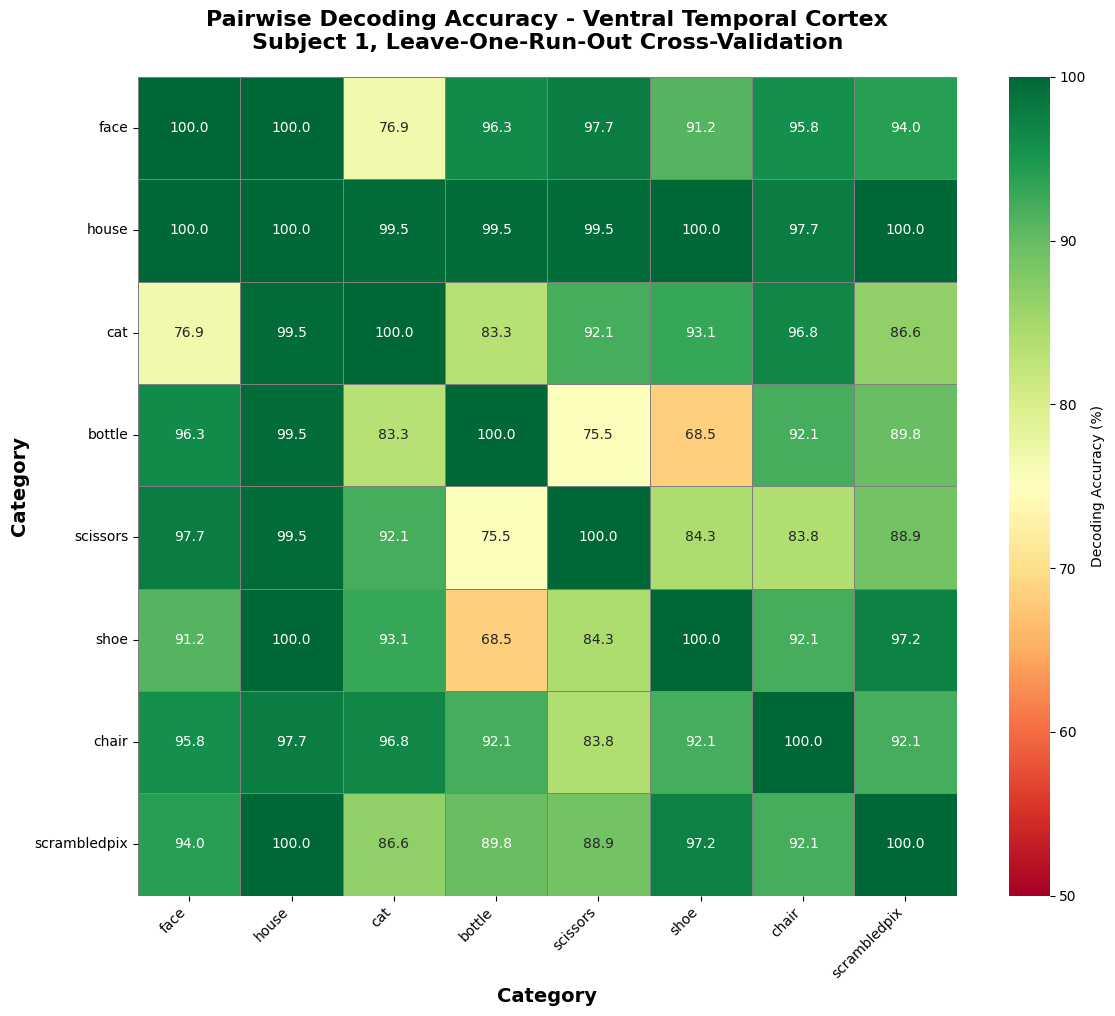

In [23]:
# Cell 10: Visualize Confusion Matrix as Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(
    accuracy_matrix * 100,  # Convert to percentage
    annot=True,             # Show numbers
    fmt='.1f',              # 1 decimal place
    cmap='RdYlGn',          # Red (low) → Yellow (mid) → Green (high)
    vmin=50, vmax=100,      # Scale from 50-100%
    xticklabels=categories,
    yticklabels=categories,
    cbar_kws={'label': 'Decoding Accuracy (%)'},
    square=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Pairwise Decoding Accuracy - Ventral Temporal Cortex\nSubject 1, Leave-One-Run-Out Cross-Validation', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=14, fontweight='bold')
plt.ylabel('Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save figure
plt.savefig('/Users/momosarki/Documents/cmn-practical/project2/figures/confusion_matrix_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("✅ Heatmap saved to: project2/figures/confusion_matrix_heatmap.png")

plt.show()

In [24]:
# Test: Does standardization method matter?

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("🧪 Testing standardization impact on accuracy...")
print("="*70)

# Pick a few representative pairs
test_pairs = [
    ('face', 'house'),      # Easy pair
    ('bottle', 'shoe'),     # Hard pair
    ('cat', 'scissors')     # Medium pair
]

for cat1, cat2 in test_pairs:
    print(f"\n{cat1} vs {cat2}:")
    
    mask_pair = (y_task == cat1) | (y_task == cat2)
    X_pair = X_task[mask_pair]
    y_pair = y_task[mask_pair]
    runs_pair = runs_task[mask_pair]
    
    # Method 1: Current (leaky) - already standardized
    logo = LeaveOneGroupOut()
    svm = SVC(kernel='linear', C=1.0)
    scores_leaky = []
    
    for train_idx, test_idx in logo.split(X_pair, y_pair, groups=runs_pair):
        X_train, X_test = X_pair[train_idx], X_pair[test_idx]
        y_train, y_test = y_pair[train_idx], y_pair[test_idx]
        
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)
        scores_leaky.append(score)
    
    acc_leaky = np.mean(scores_leaky)
    
    # Method 2: Proper - standardize within each fold
    # Use RAW unstandardized data
    masker_raw = NiftiMasker(mask_img=haxby.mask_vt[0], standardize=False)
    X_raw = masker_raw.fit_transform(haxby.func[0])
    X_raw_task = X_raw[y != 'rest']
    X_raw_pair = X_raw_task[mask_pair]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', C=1.0))
    ])
    
    scores_proper = []
    for train_idx, test_idx in logo.split(X_raw_pair, y_pair, groups=runs_pair):
        X_train, X_test = X_raw_pair[train_idx], X_raw_pair[test_idx]
        y_train, y_test = y_pair[train_idx], y_pair[test_idx]
        
        # Pipeline standardizes ONLY on training data
        pipeline.fit(X_train, y_train)
        score = pipeline.score(X_test, y_test)
        scores_proper.append(score)
    
    acc_proper = np.mean(scores_proper)
    
    print(f"  Leaky standardization:  {acc_leaky:.1%}")
    print(f"  Proper standardization: {acc_proper:.1%}")
    print(f"  Difference: {(acc_leaky - acc_proper)*100:+.1f} percentage points")

🧪 Testing standardization impact on accuracy...

face vs house:


/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_raw = masker_raw.fit_transform(haxby.func[0])
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  X_raw = masker_raw.fit_transform(haxby.func[0])


  Leaky standardization:  100.0%
  Proper standardization: 100.0%
  Difference: +0.0 percentage points

bottle vs shoe:


/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_raw = masker_raw.fit_transform(haxby.func[0])
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  X_raw = masker_raw.fit_transform(haxby.func[0])


  Leaky standardization:  68.5%
  Proper standardization: 69.0%
  Difference: -0.5 percentage points

cat vs scissors:


/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X_raw = masker_raw.fit_transform(haxby.func[0])
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2387610811.py:42: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  X_raw = masker_raw.fit_transform(haxby.func[0])


  Leaky standardization:  92.1%
  Proper standardization: 91.7%
  Difference: +0.5 percentage points


In [25]:
# Sanity check: Label permutation test

print("🎲 Label Permutation Test (Sanity Check)")
print("="*70)
print("If we randomly shuffle labels, accuracy should drop to ~50%\n")

# Test on 3 pairs
test_pairs = [
    ('face', 'house', 100.0),
    ('bottle', 'shoe', 68.5),
    ('cat', 'scissors', 92.1)
]

for cat1, cat2, real_acc in test_pairs:
    print(f"\n{cat1} vs {cat2} (real accuracy: {real_acc:.1%}):")
    
    mask_pair = (y_task == cat1) | (y_task == cat2)
    X_pair = X_task[mask_pair]
    y_pair = y_task[mask_pair].copy()  # Copy so we can shuffle
    runs_pair = runs_task[mask_pair]
    
    # Shuffle labels randomly
    np.random.seed(42)
    y_shuffled = y_pair.copy()
    np.random.shuffle(y_shuffled)  # Random permutation
    
    # Train with shuffled labels
    logo = LeaveOneGroupOut()
    svm = SVC(kernel='linear', C=1.0)
    scores_shuffled = []
    
    for train_idx, test_idx in logo.split(X_pair, y_shuffled, groups=runs_pair):
        X_train, X_test = X_pair[train_idx], X_pair[test_idx]
        y_train, y_test = y_shuffled[train_idx], y_shuffled[test_idx]
        
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)
        scores_shuffled.append(score)
    
    acc_shuffled = np.mean(scores_shuffled)
    
    print(f"  Real labels:     {real_acc:.1%}")
    print(f"  Shuffled labels: {acc_shuffled:.1%}")
    print(f"  Expected ~50%:   {abs(acc_shuffled - 0.5) < 0.1}")
    
    if acc_shuffled > 60:
        print(f"  ⚠️  WARNING: Shuffled accuracy suspiciously high!")
    else:
        print(f"  ✅ Shuffled accuracy at chance - results are real!")

🎲 Label Permutation Test (Sanity Check)
If we randomly shuffle labels, accuracy should drop to ~50%


face vs house (real accuracy: 10000.0%):
  Real labels:     10000.0%
  Shuffled labels: 48.1%
  Expected ~50%:   True
  ✅ Shuffled accuracy at chance - results are real!

bottle vs shoe (real accuracy: 6850.0%):
  Real labels:     6850.0%
  Shuffled labels: 53.2%
  Expected ~50%:   True
  ✅ Shuffled accuracy at chance - results are real!

cat vs scissors (real accuracy: 9210.0%):


/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2953942224.py:25: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(y_shuffled)  # Random permutation
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2953942224.py:25: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(y_shuffled)  # Random permutation
/var/folders/3w/6gfyr3995013t40m06__sqdc0000gn/T/ipykernel_2546/2953942224.py:25: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tens

  Real labels:     9210.0%
  Shuffled labels: 40.7%
  Expected ~50%:   True
  ✅ Shuffled accuracy at chance - results are real!


✅ Bar chart saved!


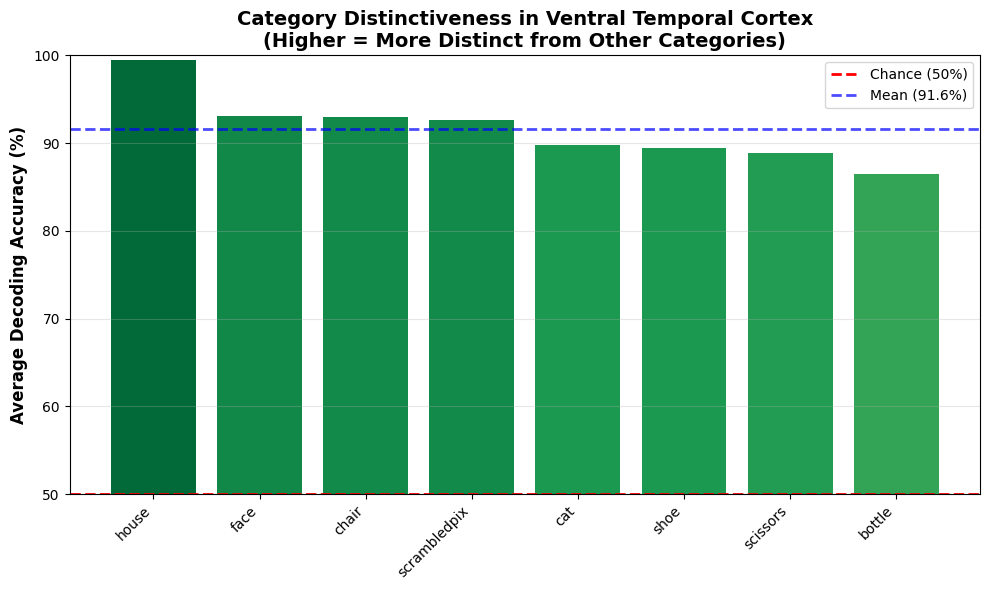


📈 CATEGORY DISTINCTIVENESS RANKING:
  1. house       :  99.5%
  2. face        :  93.1%
  3. chair       :  92.9%
  4. scrambledpix:  92.7%
  5. cat         :  89.7%
  6. shoe        :  89.5%
  7. scissors    :  88.8%
  8. bottle      :  86.4%


In [26]:
# Cell 11: Category Distinctiveness Analysis

# Calculate mean accuracy for each category (how distinct it is from all others)
category_distinctiveness = []
for i, cat in enumerate(categories):
    # Get all accuracies involving this category (excluding diagonal)
    row_accs = np.concatenate([accuracy_matrix[i, :i], accuracy_matrix[i, i+1:]])
    mean_acc = np.mean(row_accs)
    category_distinctiveness.append((cat, mean_acc))

# Sort by distinctiveness
category_distinctiveness.sort(key=lambda x: x[1], reverse=True)
cats_sorted, accs_sorted = zip(*category_distinctiveness)

# Plot
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.array(accs_sorted))
bars = plt.bar(range(len(cats_sorted)), np.array(accs_sorted) * 100, color=colors)

plt.xticks(range(len(cats_sorted)), cats_sorted, rotation=45, ha='right')
plt.ylabel('Average Decoding Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Category Distinctiveness in Ventral Temporal Cortex\n(Higher = More Distinct from Other Categories)', 
          fontsize=14, fontweight='bold')
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Chance (50%)')
plt.axhline(y=np.mean(list(results.values()))*100, color='blue', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Mean ({np.mean(list(results.values()))*100:.1f}%)')
plt.ylim(50, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('category_distinctiveness.png', dpi=300, bbox_inches='tight')
print("✅ Bar chart saved!")
plt.show()

print("\n📈 CATEGORY DISTINCTIVENESS RANKING:")
for i, (cat, acc) in enumerate(category_distinctiveness, 1):
    print(f"  {i}. {cat:12s}: {acc*100:5.1f}%")